# Prétraitement des données texte

In [1]:
from IPython.display import display, HTML
display(HTML("<div style='text-align: center;'><img src='logo.png' alt='Logo' width='400'></div>"))

« J’ai regroupé toutes les fonctions de traitement de texte, d’image et d’extraction de caractéristiques dans un fichier fonctions.py dédié, afin de structurer mon projet de manière modulaire. Cette séparation du code permet une meilleure lisibilité, une réutilisation aisée dans d’autres scripts, et simplifie la maintenance du projet. Chaque fonction est commentée, organisée par thème (prétraitement, vectorisation, traitement d’images), et prête à être intégrée dans un pipeline complet de classification automatique. »

In [2]:
import pandas as pd
from pandas.api.types import CategoricalDtype
from pandasql import sqldf
import numpy as np
import fonctions as fc
import importlib
import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import time

from scipy import stats 
from scipy.stats import f_oneway, kruskal
from scipy.stats import shapiro, kstest, yeojohnson, boxcox

from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, LatentDirichletAllocation, NMF
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, roc_auc_score, roc_curve, adjusted_rand_score

from glob import glob
import keras.preprocessing.image

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import Constant
import gensim
from gensim.models import Word2Vec
from transformers import BertTokenizer, BertModel, TFAutoModel, AutoTokenizer
from IPython.display import display, Markdown

import re
import string

import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize, wordpunct_tokenize, RegexpTokenizer
from nltk.corpus import stopwords, words, wordnet, brown
from nltk.tag import pos_tag

from wordcloud import WordCloud
from PIL import Image

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [3]:
!python --version

Python 3.10.16


In [4]:
importlib.reload(fc)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


<module 'fonctions' from 'C:\\Users\\steph\\Documents\\OPENCLASSROOMS\\Projets\\Projet6_Classifiez_automatiquement_des_biens_de_consommation\\fonctions.py'>

In [5]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('words')
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\steph\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

# Enoncé
#### Vous êtes Data Scientist au sein de l’entreprise "Place de marché”, qui souhaite lancer une marketplace e-commerce.

- Sur cette place de marché anglophone, des vendeurs proposent des articles à des acheteurs en postant une photo et une description.

- Pour l'instant, l'attribution de la catégorie d'un article est effectuée manuellement par les vendeurs, et est donc peu fiable. De plus, le volume des articles est pour l’instant très petit.

- Pour rendre l’expérience utilisateur des vendeurs (faciliter la mise en ligne de nouveaux articles) et des acheteurs (faciliter la recherche de produits) la plus fluide possible, et dans l'optique d'un passage à l'échelle, il devient nécessaire d'automatiser cette tâche d‘attribution de la categorie.

- Linda, Lead Data Scientist, vous demande donc d'étudier la faisabilité d'un moteur de classification des articles en différentes catégories, à partir du texte (en anglais) et de l’image comme dans l’illustration ci-dessous.

### Missions
- Ta mission sera de réaliser une étude de faisabilité d'un moteur de classification automatique d’articles, en utilisant leur image et leur description sur le jeu de données d'articles disponible dans la première pièce jointe de ce mail..

# I- Visualisation des données

**# Lecture du fichier CSV en utilisant le moteur 'python' (plus tolérant que 'c')**
**'on_bad_lines="skip"' permet d'ignorer les lignes mal formatées (ex: guillemets non fermés)**

In [6]:
df = pd.read_csv('flipkart_com-ecommerce_sample_1050.csv')
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."


In [7]:
print('Ce jeu de donnée comporte ' + str(df.shape[0]) + ' lignes et ' + str(df.shape[1]) + ' colonnes')

Ce jeu de donnée comporte 1050 lignes et 15 colonnes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  1050 non-null   object 
 1   crawl_timestamp          1050 non-null   object 
 2   product_url              1050 non-null   object 
 3   product_name             1050 non-null   object 
 4   product_category_tree    1050 non-null   object 
 5   pid                      1050 non-null   object 
 6   retail_price             1049 non-null   float64
 7   discounted_price         1049 non-null   float64
 8   image                    1050 non-null   object 
 9   is_FK_Advantage_product  1050 non-null   bool   
 10  description              1050 non-null   object 
 11  product_rating           1050 non-null   object 
 12  overall_rating           1050 non-null   object 
 13  brand                    712 non-null    object 
 14  product_specifications  

In [9]:
df.dtypes.value_counts()

object     12
float64     2
bool        1
Name: count, dtype: int64

uniq_id                      0
crawl_timestamp              0
product_url                  0
product_name                 0
product_category_tree        0
pid                          0
retail_price                 1
discounted_price             1
image                        0
is_FK_Advantage_product      0
description                  0
product_rating               0
overall_rating               0
brand                      338
product_specifications       1
dtype: int64

<Axes: >

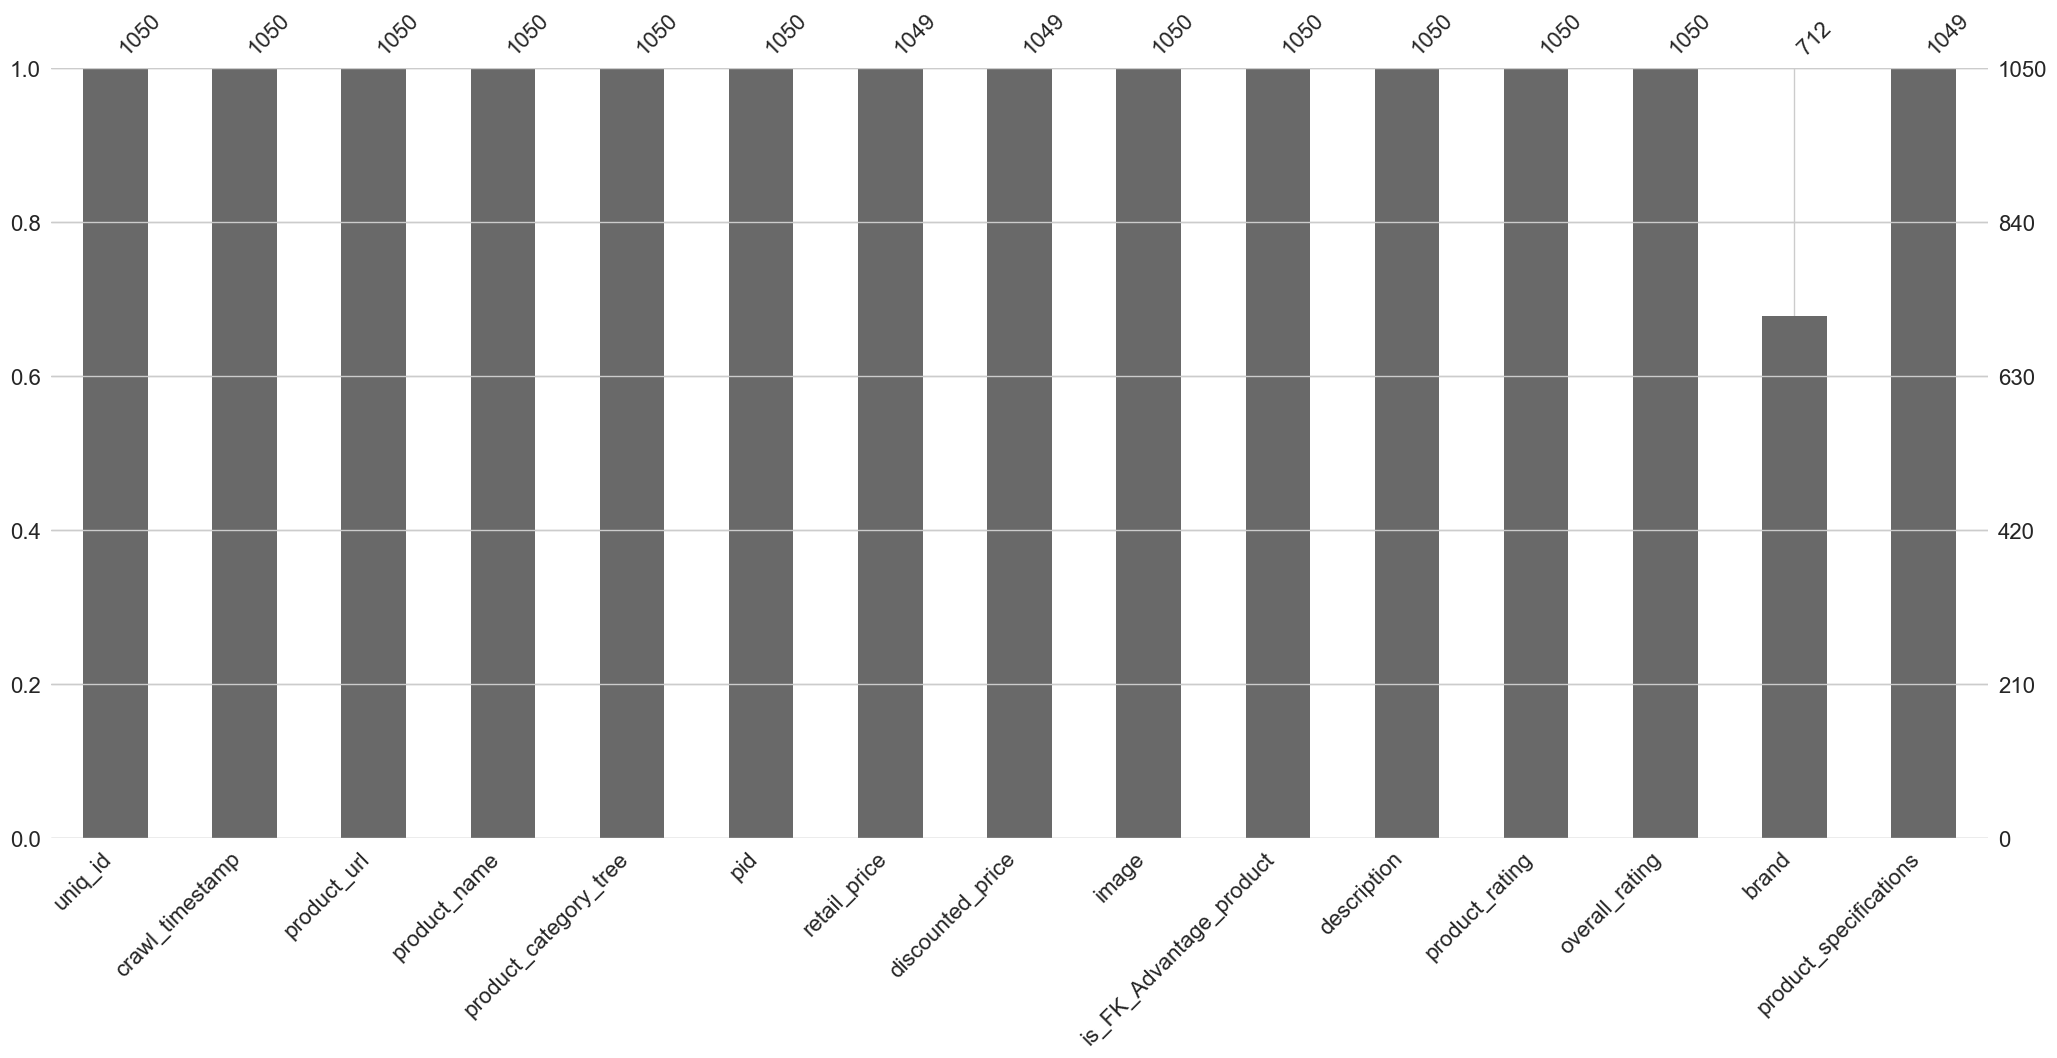

In [10]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
display(df.isna().sum())
msno.bar(df)

In [11]:
df.describe()

,retail_price,discounted_price
count,1049.000000,1049.000000
mean,2186.197331,1584.527169
std,7639.229411,7475.099680
min,35.000000,35.000000
25%,555.000000,340.000000
50%,999.000000,600.000000
75%,1999.000000,1199.000000
max,201000.000000,201000.000000


# II - Nettoyage des données
- Suppression des lignes dupliquées s'il y en a

In [12]:
print("Le nombre de doublons dans df est de : ", df[df.duplicated()].shape[0])
df = df.drop_duplicates(keep='first')

Le nombre de doublons dans df est de :  0


## 2.1) Nettoyage de la variable 'product_name'
- Vérification de la similarité entre les colonnes **'product_name'** et **'description'** pour éviter les redondances

In [13]:
#Extraction des mots uniques pour chaque produit  
df['product_name_words'] = df['product_name'].apply(fc.extract_unique_words)
df['description_words'] = df['description'].apply(fc.extract_unique_words)

#Retrouve-t-on les mots de 'product_name' dans 'description' ?
df['words_match'] = df.apply(lambda x: x['product_name_words'].issubset(x['description_words']), axis=1)
df['words_match'].value_counts()

words_match
True    1050
Name: count, dtype: int64

In [14]:
df[['product_name', 'description']]

,product_name,description
0,Elegance Polyester Multicolor Abstract Eyelet ...,Key Features of Elegance Polyester Multicolor ...
1,Sathiyas Cotton Bath Towel,Specifications of Sathiyas Cotton Bath Towel (...
2,Eurospa Cotton Terry Face Towel Set,Key Features of Eurospa Cotton Terry Face Towe...
3,SANTOSH ROYAL FASHION Cotton Printed King size...,Key Features of SANTOSH ROYAL FASHION Cotton P...
4,Jaipur Print Cotton Floral King sized Double B...,Key Features of Jaipur Print Cotton Floral Kin...
...,...,...
1045,Oren Empower Extra Large Self Adhesive Sticker,Oren Empower Extra Large Self Adhesive Sticker...
1046,Wallmantra Large Vinyl Sticker Sticker,Wallmantra Large Vinyl Sticker Sticker (Pack o...
1047,Uberlyfe Extra Large Pigmented Polyvinyl Films...,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...
1048,Wallmantra Medium Vinyl Sticker Sticker,Buy Wallmantra Medium Vinyl Sticker Sticker fo...


Tous les mots compris dans la colonne **'product_name'** sont aussi présents à chaque fois dans la colonne **'description'**. Il est inutile de garder cette colonne car elle est redondante. Je commence la sélectionne des colonnes pertinentes pour la suite du projet :

In [15]:
df = df[['product_category_tree', 'description']]
print(df.shape)

(1050, 2)


## 2.2) Création de la variable **'main_categorie'** qui sera ma target
- Je cherche à extraire de la variable 'product_category_tree' la catégorie principale de chaque produit afin d'en faire une nouvelle variable que je vais nommer 'main_category'

In [16]:
# Elimination des crochets et des guillemets de la variable 'product_category_tree'
df["product_category_tree"] = df["product_category_tree"].str.replace("[", "")
df["product_category_tree"] = df["product_category_tree"].str.replace("]", "")
df["product_category_tree"] = df["product_category_tree"].str.replace('"', '')

**La nouvelle variable 'main_category' représente la catégorie principale extraite de chaque produit à partir de 'product_category_tree'**

main_category
home furnishing                 150
baby care                       150
watches                         150
home decor and festive needs    150
kitchen and dining              150
beauty and personal care        150
computers                       150
Name: count, dtype: int64


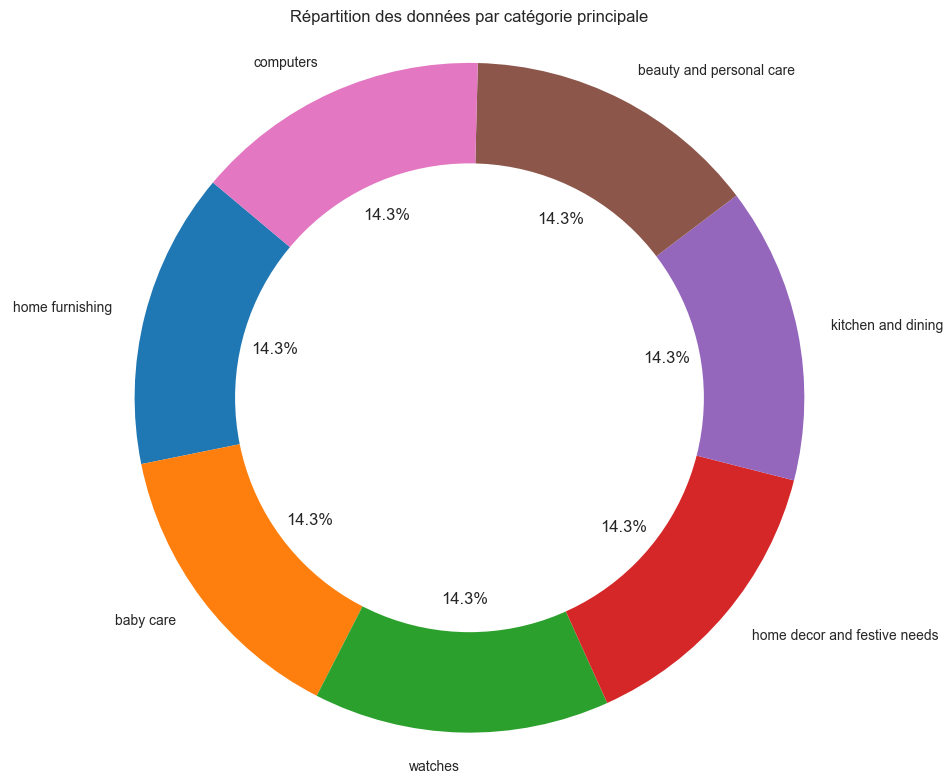

In [17]:
# Création de la variable 'main_category'
df["main_category"] = df["product_category_tree"].str.split('>>').str[0]

# Nettoyage (lower // remplacer '&' par 'and' // supprimer les espaces)
df["main_category"] = df["main_category"].str.lower()
df["main_category"] = df["main_category"].str.replace("&", 'and')
df['main_category'] = df['main_category'].str.strip()

#Donut Chart
nb_category = df['main_category'].value_counts()
print(nb_category)
labels = nb_category.index

plt.figure(figsize=(10, 8))
plt.pie(nb_category, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.axis('equal')
plt.title('Répartition des données par catégorie principale')
plt.tight_layout()
plt.show()

On a donc 7 catégories principales de produits, avec chacune 150 produits :

- home furnishing
- baby care
- watches
- home decord and festive needs
- kitchen and dining
- beauty and personal Care
- computer

## 2.3) Pre-nettoyage de la variable 'description'
Je vais appliquer plusieurs étapes de nettoyage à ma colonne description :

- **Tokenization** : La tokenization est le processus de division d'un texte en unités plus petites appelées tokens. Ces tokens peuvent être des mots      individuels ou des phrases. Par exemple, dans la phrase "Le chat dort", la tokenization séparera les mots en tokens individuels, soit ["Le",     "chat", "dort"].

- **Stop Words** : Les stop words sont des mots très courants et généralement peu informatifs qui sont souvent éliminés lors du traitement du langage      naturel pour améliorer les performances des algorithmes et réduire le bruit. Ces mots incluent des mots comme "le", "la", "et", "de", etc.

- **Lemmatisation** : La lemmatisation est le processus de normalisation des mots en les ramenant à leur forme de base ou de racine, appelée lemmes.       Par exemple, les mots "mangé", "mangeait" et "mangeront" seraient tous ramenés à leur lemme commun "manger".

J'effectue ensuite une jointure de la description de l'ensemble des produits

In [18]:
raw_corpus = " ".join(df.description.values)
raw_corpus[:1300]

'Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty given by the soothing prints. Bring home the elegant curtain that softly filters light in your room so that you

In [19]:
print(f'Le corpus description des produits comprend {len(raw_corpus)} tokens.')

Le corpus description des produits comprend 498561 tokens.


- J'effectue les étapes de nettoyage citées précédemment

In [20]:
# Nettoyage de raw_corpus
corpus = fc.process_description(raw_corpus)
fc.display_tokens_info(corpus)

nb tokens : 61786, nb tokens uniques : 5548
['key', 'feature', 'elegance', 'polyester', 'multicolor', 'abstract', 'eyelet', 'door', 'curtain', 'floral', 'curtain', 'elegance', 'polyester', 'multicolor', 'abstract', 'eyelet', 'door', 'curtain', '213', 'cm', 'height', 'pack', '2', 'price', 'r', '899', 'curtain', 'enhances', 'look', 'interior', 'curtain', 'made', '100', 'high', 'quality', 'polyester', 'fabric', 'feature', 'eyelet', 'style', 'stitch', 'metal', 'ring', 'make', 'room', 'environment', 'romantic', 'loving', 'curtain', 'ant']


In [21]:
# Tokens présent une seule fois
tmp_corpus = pd.Series(corpus).value_counts()
liste_unique_words = tmp_corpus[tmp_corpus == 1]
print(liste_unique_words[:30])
print(f'Parmi les 5548 tokens uniques du corpus description, {len(liste_unique_words)} apparaissent une seule fois.')

picnic         1
boiling        1
define         1
subfreezing    1
582            1
propylene      1
gym            1
ingot          1
amongst        1
skyblue        1
tslplt02       1
hd10012        1
98             1
stearic        1
counted        1
girlswatch     1
arrival        1
crown          1
glycol         1
paraben        1
joyous         1
vegetarian     1
endless        1
betaine        1
propyl         1
habit          1
glycerin       1
cocoamido      1
behind         1
trek           1
Name: count, dtype: int64
Parmi les 5548 tokens uniques du corpus description, 1788 apparaissent une seule fois.


- Je vient de faire le nettoyage sur la description de l'ensemble des produits. Je vais maintenant créé une nouvelle variable **'pre_clen_description'** qui va permettre d'effectuer le nettoyage sur chaque produit individuellement.

In [22]:
df["pre_clean_description"] = df['description'].apply(fc.pre_cleaning)
df.head()

,product_category_tree,description,main_category,pre_clean_description
0,Home Furnishing >> Curtains & Accessories >> C...,Key Features of Elegance Polyester Multicolor ...,home furnishing,key feature elegance polyester multicolor abst...
1,Baby Care >> Baby Bath & Skin >> Baby Bath Tow...,Specifications of Sathiyas Cotton Bath Towel (...,baby care,specification sathiyas cotton bath towel 3 bat...
2,Baby Care >> Baby Bath & Skin >> Baby Bath Tow...,Key Features of Eurospa Cotton Terry Face Towe...,baby care,key feature eurospa cotton terry face towel se...
3,Home Furnishing >> Bed Linen >> Bedsheets >> S...,Key Features of SANTOSH ROYAL FASHION Cotton P...,home furnishing,key feature santosh royal fashion cotton print...
4,Home Furnishing >> Bed Linen >> Bedsheets >> J...,Key Features of Jaipur Print Cotton Floral Kin...,home furnishing,key feature jaipur print cotton floral king si...


In [23]:
print("Description d'un produit avant le pré-nettoyage")
print("-------------------------------------------------------------")
print(df["description"][0])
print()
print("Description du même produit après un pré-nettoyage")
print("-------------------------------------------------------------")
print(df["pre_clean_description"][0])

Description d'un produit avant le pré-nettoyage
-------------------------------------------------------------
Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty gi

Quelques améliorations peuvent être apportées au processus de nettoyage de la variable **'description'** :

- **Suppression des tokens de moins de 3 caractères** : Trois caractères est un seuil généralement utilisé.

- **Suppression des tokens présent qu'une seule fois** : Cela peut être considéré comme du bruit.

- **Élimination des URL, balises HTML, caractères non ASCII** : Par précaution.

## 2.4) Nettoyage final de la variable **'description'**

In [24]:
# Lower()
df['clean_description'] = df['description'].apply(lambda x : x.lower())

# Elimination des adresses URL // balises HTML // caractères non-ASCII
df['clean_description'] = df['clean_description'].apply(lambda x : fc.clean_text(x))

#Tokenization 
tokenizer = RegexpTokenizer(r'\w+')
df['clean_description'] = df['clean_description'].apply(tokenizer.tokenize)

# Élimination des stopwords anglais
stop_words = set(stopwords.words('english'))
df['clean_description'] = df['clean_description'].apply(lambda x: [w for w in x if w not in stop_words])

# Elimination des mots non anglais
english_words = set(nltk.corpus.words.words())
df['clean_description'] = df['clean_description'].apply(lambda x: [w for w in x if w in english_words])

# Suppression des tokens de moins de 3 caractères
df['clean_description'] = df['clean_description'].apply(lambda x: [w for w in x if len(w) >= 3])

# Suppression des mots n'apparaissant qu'une fois
df['clean_description'] = df['clean_description'].apply(lambda x: [w for w in x if w not in liste_unique_words])

# Lemmatization
lemmatizer = WordNetLemmatizer()
df['clean_description'] = df['clean_description'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

# Jointure des tokens 
df['clean_description'] = df['clean_description'].apply(lambda x: " ".join(x))

df.head()

,product_category_tree,description,main_category,pre_clean_description,clean_description
0,Home Furnishing >> Curtains & Accessories >> C...,Key Features of Elegance Polyester Multicolor ...,home furnishing,key feature elegance polyester multicolor abst...,key elegance polyester multicolor abstract eye...
1,Baby Care >> Baby Bath & Skin >> Baby Bath Tow...,Specifications of Sathiyas Cotton Bath Towel (...,baby care,specification sathiyas cotton bath towel 3 bat...,cotton bath towel bath towel red yellow blue b...
2,Baby Care >> Baby Bath & Skin >> Baby Bath Tow...,Key Features of Eurospa Cotton Terry Face Towe...,baby care,key feature eurospa cotton terry face towel se...,key cotton terry face towel set size small hei...
3,Home Furnishing >> Bed Linen >> Bedsheets >> S...,Key Features of SANTOSH ROYAL FASHION Cotton P...,home furnishing,key feature santosh royal fashion cotton print...,key royal fashion cotton printed king sized do...
4,Home Furnishing >> Bed Linen >> Bedsheets >> J...,Key Features of Jaipur Print Cotton Floral Kin...,home furnishing,key feature jaipur print cotton floral king si...,key print cotton floral king sized double cott...


- Je vais aussi éliminer les tokens communs aux 7 catégories de la variable **'main_category'**

In [25]:
home_furnishing = df[df['main_category'].str.contains("home furnishing")]
baby_care = df[df["main_category"].str.contains("baby care")]
watches = df[df["main_category"].str.contains("watches")]
home_decor_and_festive_needs = df[df["main_category"].str.contains("home decor and festive needs")]
kitchen_and_dining = df[df["main_category"].str.contains("kitchen and dining")]
beauty_and_personal_care = df[df["main_category"].str.contains("beauty and personal care")]
computers = df[df["main_category"].str.contains("computers")]

In [26]:
# Création des 7 corpus 
home_furnishing_corpus = " ".join(home_furnishing.clean_description.values)
baby_care_corpus = " ".join(baby_care.clean_description.values)
watches_corpus = " ".join(watches.clean_description.values)
home_decor_and_festive_needs_corpus = " ".join(home_decor_and_festive_needs.clean_description.values)
kitchen_and_dining_corpus = " ".join(kitchen_and_dining.clean_description.values)
beauty_and_personal_care_corpus = " ".join(beauty_and_personal_care.clean_description.values)
computers_corpus = " ".join(computers.clean_description.values)

In [27]:
tokeniser= RegexpTokenizer(r'\w+')
tokens_home_furnishing = tokeniser.tokenize(home_furnishing_corpus)
tokens_home_decor_and_festive_needs = tokenizer.tokenize(home_decor_and_festive_needs_corpus)
tokens_baby_care = tokeniser.tokenize(baby_care_corpus)
tokens_watches = tokeniser.tokenize(watches_corpus)
tokens_kitchen_and_dining = tokeniser.tokenize(kitchen_and_dining_corpus)
tokens_beauty_and_personal_care = tokeniser.tokenize(beauty_and_personal_care_corpus)
tokens_computers = tokeniser.tokenize(computers_corpus)

In [28]:
tokens_communs = list(set.intersection(*map(set, [tokens_baby_care, tokens_beauty_and_personal_care, tokens_computers, tokens_home_decor_and_festive_needs, tokens_home_furnishing, tokens_kitchen_and_dining, tokens_watches])))
print(tokens_communs)

['like', 'width', 'long', 'high', 'touch', 'brand', 'suitable', 'buy', 'price', 'delivery', 'designed', 'vary', 'package', 'genuine', 'white', 'light', 'size', 'box', 'quality', 'great', 'ideal', 'height', 'content', 'cover', 'replacement', 'get', 'material', 'look', 'blue', 'world', 'way', 'may', 'made', 'weight', 'water', 'free', 'design', 'well', 'product', 'pack', 'black', 'add', 'cash', 'color', 'yes', 'life', 'number', 'shipping', 'come', 'new', 'key', 'type', 'body', 'red', 'general', 'style', 'one', 'back', 'green', 'pink', 'day']


In [29]:

display(Markdown(f"{len(tokens_communs)} mots sont communs aux 7 catégories. Leur présence pourrait entraîner une confusion lors de la classification des produits. Par conséquent, je vais éliminer ces stopwords spécifiques au projet dans une nouvelle variable **final_description**."))

61 mots sont communs aux 7 catégories. Leur présence pourrait entraîner une confusion lors de la classification des produits. Par conséquent, je vais éliminer ces stopwords spécifiques au projet dans une nouvelle variable **final_description**.

In [30]:
# Lower()
df['final_description'] = df['description'].apply(lambda x : x.lower())

# Elimination des adresses URL // balises HTML // caractères non-ASCII
df['final_description'] = df['final_description'].apply(lambda x : fc.clean_text(x))

#Tokenization 
tokenizer = RegexpTokenizer(r'\w+')
df['final_description'] = df['final_description'].apply(tokenizer.tokenize)

# Élimination des stopwords
stop_words = set(stopwords.words('english'))
df['final_description'] = df['final_description'].apply(lambda x: [w for w in x if w not in stop_words])

# Elimination des stopwords (communs aux 7 catégories)
df["final_description"] = df["final_description"].apply(lambda x : [w for w in x if w not in tokens_communs])

# Elimination des mots non anglais
english_words = set(nltk.corpus.words.words())
df['final_description'] = df['final_description'].apply(lambda x: [w for w in x if w in english_words])

# Suppression des mots n'apparaissant qu'une fois
df['final_description'] = df['final_description'].apply(lambda x: [w for w in x if w not in liste_unique_words])

# Elimination des mots possédant un mélange de chiffres et de lettres
df["final_description"] = df["final_description"].apply(lambda x : [w for w in x if w.isalpha()])

# Lemmatization
lemmatizer = WordNetLemmatizer()
df['final_description'] = df['final_description'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

# Jointure des tokens 
df['final_description'] = df['final_description'].apply(lambda x: " ".join(x))

df.head()

,product_category_tree,description,main_category,pre_clean_description,clean_description,final_description
0,Home Furnishing >> Curtains & Accessories >> C...,Key Features of Elegance Polyester Multicolor ...,home furnishing,key feature elegance polyester multicolor abst...,key elegance polyester multicolor abstract eye...,elegance polyester multicolor abstract eyelet ...
1,Baby Care >> Baby Bath & Skin >> Baby Bath Tow...,Specifications of Sathiyas Cotton Bath Towel (...,baby care,specification sathiyas cotton bath towel 3 bat...,cotton bath towel bath towel red yellow blue b...,cotton bath towel bath towel yellow bath towel...
2,Baby Care >> Baby Bath & Skin >> Baby Bath Tow...,Key Features of Eurospa Cotton Terry Face Towe...,baby care,key feature eurospa cotton terry face towel se...,key cotton terry face towel set size small hei...,cotton terry face towel set small inch cotton ...
3,Home Furnishing >> Bed Linen >> Bedsheets >> S...,Key Features of SANTOSH ROYAL FASHION Cotton P...,home furnishing,key feature santosh royal fashion cotton print...,key royal fashion cotton printed king sized do...,royal fashion cotton printed king sized double...
4,Home Furnishing >> Bed Linen >> Bedsheets >> J...,Key Features of Jaipur Print Cotton Floral Kin...,home furnishing,key feature jaipur print cotton floral king si...,key print cotton floral king sized double cott...,print cotton floral king sized double cotton p...


In [31]:
print("Description d'un produit après le pré-nettoyage")
print(df['pre_clean_description'][0])
print()
print("Description du même produit après nettoyage final")
print(df['final_description'][0])

Description d'un produit après le pré-nettoyage
key feature elegance polyester multicolor abstract eyelet door curtain floral curtain elegance polyester multicolor abstract eyelet door curtain 213 cm height pack 2 price r 899 curtain enhances look interior curtain made 100 high quality polyester fabric feature eyelet style stitch metal ring make room environment romantic loving curtain ant wrinkle anti shrinkage elegant apparance give home bright modernistic appeal design surreal attention sure steal heart contemporary eyelet valance curtain slide smoothly draw apart first thing morning welcome bright sun ray want wish good morning whole world draw close evening create special moment joyous beauty given soothing print bring home elegant curtain softly filter light room get right amount sunlight specification elegance polyester multicolor abstract eyelet door curtain 213 cm height pack 2 general brand elegance designed door type eyelet model name abstract polyester door curtain set 2 mo

In [32]:
df[['description', 'final_description']].head()

,description,final_description
0,Key Features of Elegance Polyester Multicolor ...,elegance polyester multicolor abstract eyelet ...
1,Specifications of Sathiyas Cotton Bath Towel (...,cotton bath towel bath towel yellow bath towel...
2,Key Features of Eurospa Cotton Terry Face Towe...,cotton terry face towel set small inch cotton ...
3,Key Features of SANTOSH ROYAL FASHION Cotton P...,royal fashion cotton printed king sized double...
4,Key Features of Jaipur Print Cotton Floral Kin...,print cotton floral king sized double cotton p...


- Ce nettoyage rend les descriptions plus pertinentes et directement exploitables pour la classification automatique des produits.

## 2.5) WordCloud

Le **WordCloud** est une représentation visuelle de données textuelles. Il affiche les mots d’un corpus sous forme graphique, où la taille de chaque mot est proportionnelle à sa fréquence d’apparition. Les mots les plus fréquents apparaissent en plus grand, permettant ainsi de visualiser rapidement les termes dominants dans un texte.


In [33]:
df_wordcloud = df.copy()

home_furnishing = df_wordcloud[df_wordcloud['main_category'].str.contains("home furnishing")]
baby_care = df_wordcloud[df_wordcloud["main_category"].str.contains("baby care")]
watches = df_wordcloud[df_wordcloud["main_category"].str.contains("watches")]
home_decor_and_festive_needs = df_wordcloud[df_wordcloud["main_category"].str.contains("home decor and festive needs")]
kitchen_and_dining = df_wordcloud[df_wordcloud["main_category"].str.contains("kitchen and dining")]
beauty_and_personal_care = df_wordcloud[df_wordcloud["main_category"].str.contains("beauty and personal care")]
computers = df_wordcloud[df_wordcloud["main_category"].str.contains("computers")]

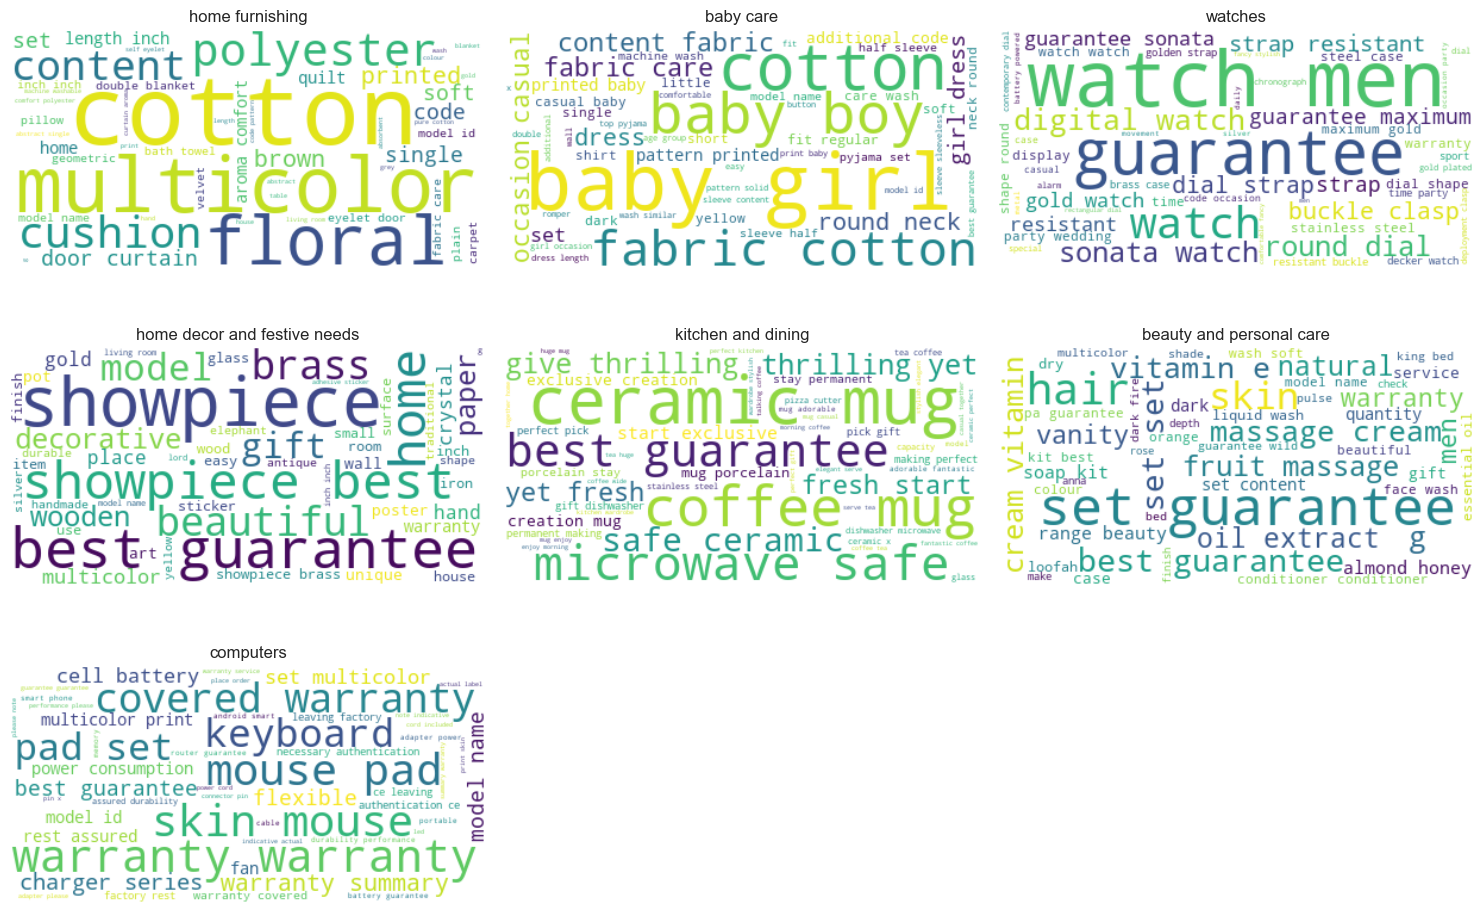

In [34]:
categories = ["home furnishing", "baby care", "watches", "home decor and festive needs", "kitchen and dining", "beauty and personal care", "computers"]

# Représentation graphique
num_categories = len(categories)
num_rows = 3  
num_cols = 3  
if num_categories < num_rows * num_cols:
    num_rows = (num_categories + num_cols - 1) // num_cols
    
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Création du corpus et du wordcloud pour chaque catégorie
for i, category in enumerate(categories): 
    corpus = " ".join(df_wordcloud[df_wordcloud['main_category'].str.contains(category)].final_description.values)
    wordcloud = WordCloud(background_color="white", max_words=50).generate(corpus)
    ax = axes[i // num_cols, i % num_cols]
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(category)
    ax.axis('off')

# Supprimer les sous-graphiques vides
for j in range(num_categories, num_rows * num_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

Je remarque que les mots les plus fréquents dans chaque catégorie sont représentatifs de leur contenu respectif. Cela appuie l'idée que le processus de pré-nettoyage a produit des nuages de mots bien représentatif. Toutefois, certaines ambiguïtés sont apparentes, comme la présence de mots communs à plusieurs catégories, tel que le mot **'cotton'** retrouvé à la fois dans la catégorie **'home furnishing'** et **'baby care'**, ou encore **'guarantee'**. Cela suggère qu'il pourrait être nécessaire d'approfondir la phase de nettoyage. Cependant, étant donné que je suis actuellement dans une phase de test de faisabilité plutôt que dans une recherche de classification parfaite, je vais m'en tenir à ces résultats.

In [35]:
df.isna().mean()

product_category_tree    0.0
description              0.0
main_category            0.0
pre_clean_description    0.0
clean_description        0.0
final_description        0.0
dtype: float64

In [36]:
# Sauvegarde du fichier avec text processing
df.to_csv("clean_description.csv", index=False)

# III- Etude de faisabilité

## 3.1) Le Bag of Words (BoW)

Le **Bag of Words (BoW)** est une technique de vectorisation qui permet de transformer du texte en données numériques. Elle consiste à représenter chaque document sous la forme d’un vecteur, où chaque dimension correspond à un mot du vocabulaire, et la valeur est généralement la fréquence d’apparition de ce mot dans le document. BoW ignore l’ordre des mots et leur contexte, mais reste une méthode simple et efficace pour les tâches de classification automatique.

## 3.1.1) CountVectorizer

`CountVectorizer` est une implémentation de BoW proposée par `scikit-learn`. Elle convertit une collection de textes en une matrice de comptage, où chaque cellule indique le nombre d’occurrences d’un mot dans un document donné. Ce vecteur peut ensuite être utilisé comme entrée pour des modèles de machine learning.


In [37]:
count_vectorizer = CountVectorizer(stop_words="english")
term_frequency = count_vectorizer.fit_transform(df["final_description"])

# Création d'un dataframe
bow_df = pd.DataFrame(term_frequency.toarray(), columns=count_vectorizer.get_feature_names_out())
bow_df.head()

,aa,ability,able,abode,abroad,absorbency,absorbent,absorbing,abstract,accent,...,year,yellow,york,young,youth,youthful,zero,zinc,zipper,zone
0,0,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3.1.2) Réduction en 2 dimensions

Une réduction en deux dimensions est nécessaire dans ce projet afin de visualiser les produits sur un graphique 2D. Chaque produit sera représenté par un point, et la couleur de ce point indiquera la catégorie réelle du produit. Cela permet d'évaluer visuellement la séparabilité des classes dans l’espace vectoriel obtenu.

Je vais effectuer cette réduction avec deux techniques complémentaires : **PCA** et dans un second temps avec un **t-SNE**.

### La PCA (Analyse en Composantes Principales)

La **PCA (Principal Component Analysis)** est une méthode de réduction de dimensionnalité qui projette les données dans un nouvel espace de dimension inférieure, en maximisant la variance conservée. Elle permet de simplifier les données tout en conservant l’essentiel de l’information, ce qui est utile pour éliminer le bruit et la redondance avant une visualisation ou une modélisation.


In [38]:
print(bow_df.shape)
pca = PCA(n_components=0.99)
feat_pca = pca.fit_transform(bow_df)
print(feat_pca.shape)

(1050, 2069)
(1050, 445)


### Le t-SNE

En utilisant **t-SNE** après une **PCA**, je réduit d’abord la dimensionnalité des données pour simplifier leur structure, ce qui permet ensuite à t-SNE de mieux préserver les relations complexes entre les points lors de la projection en deux dimensions.


In [39]:
# Réduction de dimension supplémentaire avec t-SNE
start_time_tsne = time.time()

#tsne = TSNE(n_components=2, perplexity=10, max_iter=2000, init='pca', random_state=42)
#tsne = TSNE(n_components=2, perplexity=15, max_iter=2000, init='pca', random_state=42)
#tsne = TSNE(n_components=2, perplexity=25, max_iter=2000, init='pca', random_state=42)
tsne = TSNE(n_components=2, perplexity=35, max_iter=2000, init='random', random_state=42)

X_tsne = tsne.fit_transform(feat_pca)
end_time_tsne = time.time() - start_time_tsne
print("Temps de t-SNE :", "%.2f" % end_time_tsne, "secondes")

Temps de t-SNE : 19.60 secondes


## Kmeans

In [40]:
# K-Means
kmeans = KMeans(n_clusters=7, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_tsne)

# Stocker les résultats du t-SNE et du clustering
df_tsne_kmeans = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
df_tsne_kmeans["class"] = df["main_category"]
df_tsne_kmeans["cluster"] = cluster_labels

# Calcul de l'ARI
ari = adjusted_rand_score(df_tsne_kmeans['class'], df_tsne_kmeans['cluster'])
print(f'ARI avec Bag of Words : {ari}')


ARI avec Bag of Words : 0.4492821428095349


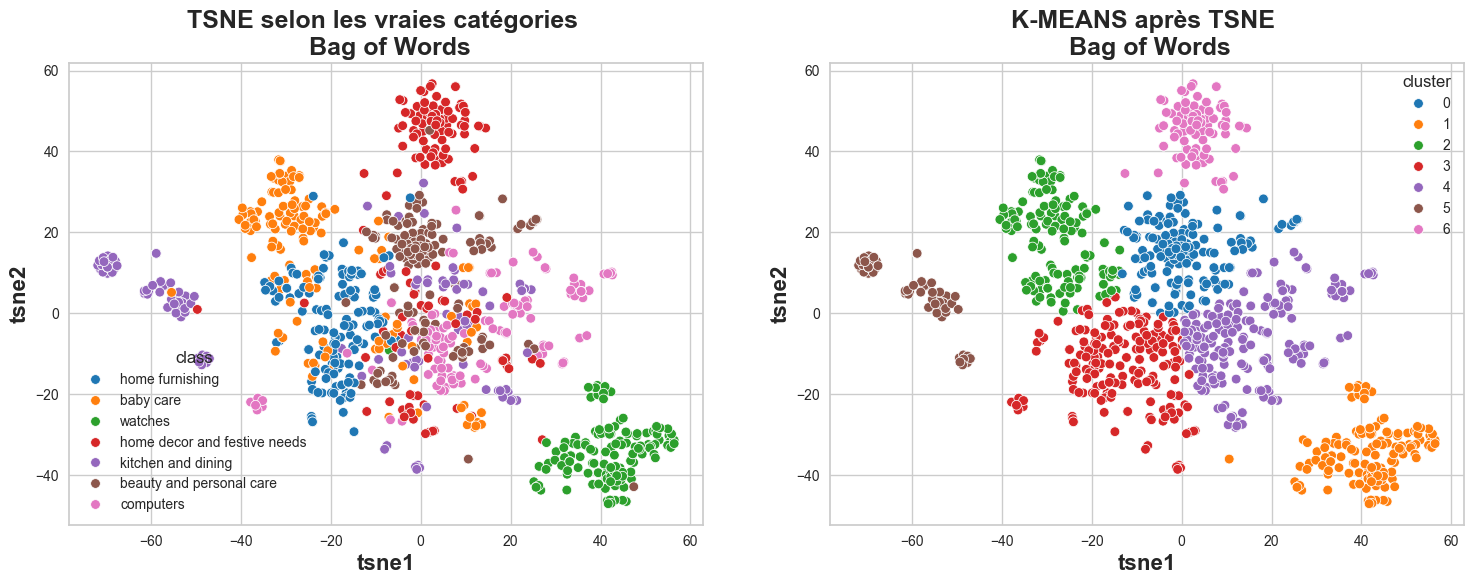

In [41]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
with sns.color_palette(palette="tab10"):
    plt.rcParams.update({"font.size": 12})
    sns.scatterplot(ax=axes[0], data=df_tsne_kmeans, x="tsne1", y="tsne2", hue="class", legend="brief")
    axes[0].set_xlabel("tsne1", fontsize=16, fontweight="bold")
    axes[0].set_ylabel("tsne2", fontsize=16, fontweight="bold")
    axes[0].set_title("TSNE selon les vraies catégories \n Bag of Words", fontsize=18, fontweight="bold")
    sns.scatterplot(ax=axes[1], data=df_tsne_kmeans, x="tsne1", y="tsne2", hue="cluster", palette="tab10", legend="brief")
    axes[1].set_xlabel("tsne1", fontsize=16, fontweight="bold")
    axes[1].set_ylabel("tsne2", fontsize=16, fontweight="bold")
    axes[1].set_title("K-MEANS après TSNE \n Bag of Words", fontsize=18, fontweight="bold")
plt.show()

- L’utilisation de la technique BoW permet d’obtenir des résultats satisfaisants, avec notamment une bonne identification des catégories *watches* et *home decor and festive needs*. Je vais maintenant approfondir l’étude de faisabilité en testant la méthode TF-IDF.


## 3.2) TF-IDF

Le **TF-IDF** (Term Frequency-Inverse Document Frequency) est une mesure statistique utilisée pour évaluer l'importance d'un terme dans un document par rapport à un ensemble de documents. 

Les termes avec des scores TF-IDF élevés sont considérés comme importants pour un document particulier, tout en étant peu fréquents dans l'ensemble du corpus. Cela les rend particulièrement discriminants pour des tâches telles que la recherche d'information ou la classification de texte.

#### Term Frequency (TF)

La fréquence du terme dans un document, calculée comme le nombre de fois où le terme *t* apparaît dans le document *d* divisé par le nombre total de termes dans ce document.

TF(d, t) = (Nombre de fois où le terme t apparaît dans le document d) / (Nombre total de termes dans le document d)

#### Inverse Document Frequency (IDF)

Mesure l'importance d'un terme dans l'ensemble des documents. Les termes fréquents dans beaucoup de documents ont un IDF faible, car ils sont peu discriminants.

IDF(t) = log(Nombre total de documents / Nombre de documents contenant le terme t)

#### Score TF-IDF

Le score TF-IDF est le produit de la fréquence du terme et de son importance inverse dans le corpus :

TF-IDF(d, t) = TF(d, t) * IDF(t)


In [42]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english")
term_frequency = tfidf_vectorizer.fit_transform(df["final_description"])
tfidf_df = pd.DataFrame(term_frequency.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.head()

,aa,ability,able,abode,abroad,absorbency,absorbent,absorbing,abstract,accent,...,year,yellow,york,young,youth,youthful,zero,zinc,zipper,zone
0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.197624,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,0.0,...,0.0,0.211912,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.08303,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
#PCA
print(tfidf_df.shape)
feat_pca_tfidf = pca.fit_transform(tfidf_df)

# TSNE
start_time_tsne = time.time()
tsne = TSNE(n_components=2, perplexity=30, n_iter=2000, init='random', random_state=42)
#tsne = TSNE(n_components=2, perplexity=10, max_iter=2000, init='pca', random_state=42)
tfidf_tsne = tsne.fit_transform(feat_pca_tfidf)
end_time_tsne = time.time() - start_time_tsne
print("Temps de t-SNE :", "%.2f" % end_time_tsne, "secondes")

(1050, 2069)


C:\Users\steph\anaconda3\envs\mon_env\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Temps de t-SNE : 11.62 secondes


In [44]:
# K-Means
cluster_labels_tfidf = kmeans.fit_predict(tfidf_tsne)

# Stocker les résultats du t-SNE et du clustering
tfidf_tsne_kmeans = pd.DataFrame(tfidf_tsne, columns=['tsne1', 'tsne2'])
tfidf_tsne_kmeans["class"] = df["main_category"]
tfidf_tsne_kmeans["cluster"] = cluster_labels

# Calcul de l'ARI
ari_tfidf = adjusted_rand_score(tfidf_tsne_kmeans['class'], tfidf_tsne_kmeans['cluster'])
print(f'ARI avec TF-IDF : {ari_tfidf}')

ARI avec TF-IDF : 0.4492821428095349


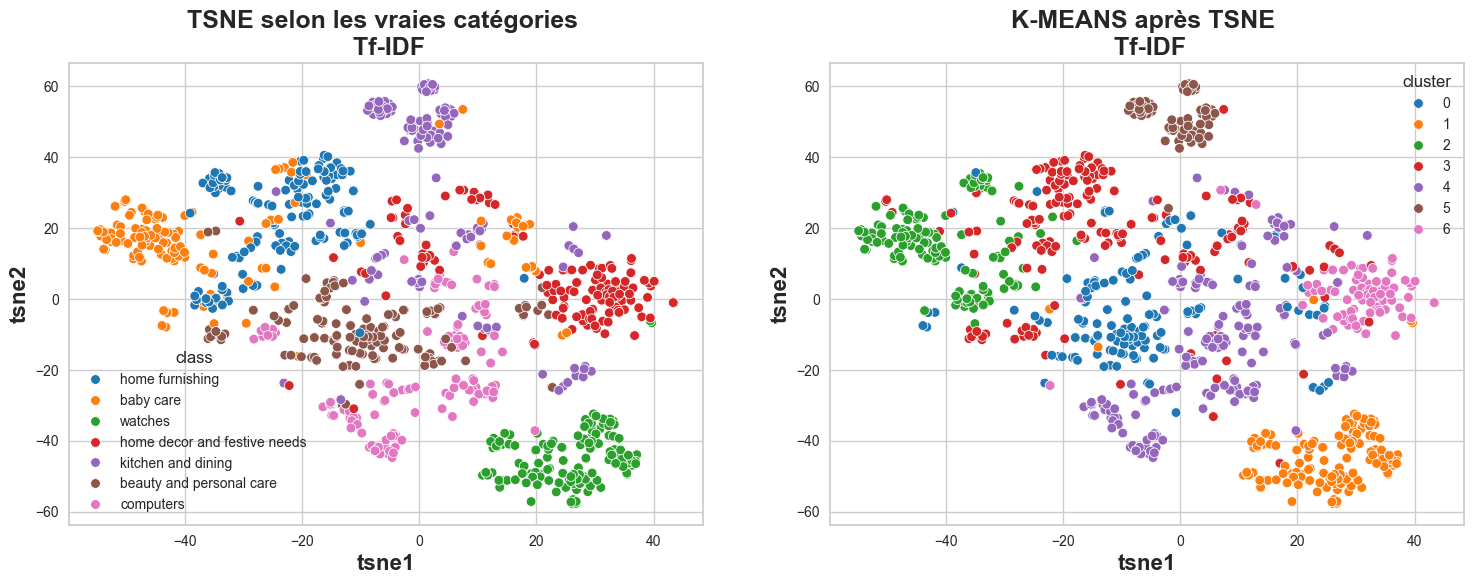

In [45]:
# Visualisation
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
with sns.color_palette(palette="tab10"):
    plt.rcParams.update({"font.size": 12})
    sns.scatterplot(ax=axes[0], data=tfidf_tsne_kmeans, x="tsne1", y="tsne2", hue="class", legend="brief")
    axes[0].set_xlabel("tsne1", fontsize=16, fontweight="bold")
    axes[0].set_ylabel("tsne2", fontsize=16, fontweight="bold")
    axes[0].set_title("TSNE selon les vraies catégories \n Tf-IDF", fontsize=18, fontweight="bold")
    sns.scatterplot(ax=axes[1], data=tfidf_tsne_kmeans, x="tsne1", y="tsne2", hue="cluster", palette="tab10", legend="brief")
    axes[1].set_xlabel("tsne1", fontsize=16, fontweight="bold")
    axes[1].set_ylabel("tsne2", fontsize=16, fontweight="bold")
    axes[1].set_title("K-MEANS après TSNE \n Tf-IDF", fontsize=18, fontweight="bold")
plt.show()

- La mesure du score ARI est identique mais visuellement, nous pouvons remarquer que la pondération conduit à une meilleure classification des produits.

### 3.3) Word2Vec

Word2Vec est une technique de représentation des mots sous forme de vecteurs dans un espace vectoriel continu. Elle permet de capturer les similarités sémantiques et syntaxiques entre les mots en les représentant par des vecteurs de nombres réels dans un espace multidimensionnel.

Cette méthode utilise un réseau de neurones artificiel entraîné sur un grand corpus de texte non annoté, afin d’apprendre des représentations vectorielles qui reflètent le contexte d’utilisation des mots.


In [46]:
# Longeur max de chaine de caractères
max_length = df["final_description"].str.len().max()
print(max_length)

# Nombre max de mots pour une chaîne de caractères
max_words = df["final_description"].str.split(" ").str.len().max()
print(max_words)

1433
210


In [47]:
w2v_size = 96
w2v_window = 5
w2v_min_count = 1
w2v_epochs = 100
maxlen = 206

# Préparation des sentences (tokenization)
sentences = df["final_description"].to_list()
sentences = [gensim.utils.simple_preprocess(text) for text in sentences]

In [48]:
# Création et entraînement du modèle Word2Vec
print("Création et entrainement du modèle Word2Vec")
w2v_model = gensim.models.Word2Vec(min_count=w2v_min_count, window=w2v_window,
                                   vector_size=w2v_size)

w2v_model.build_vocab(sentences)
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=w2v_epochs)

model_vectors = w2v_model.wv
w2v_words = model_vectors.index_to_key
print("Vocabulary size:", len(w2v_words))
print("Word2Vec trained")  

Création et entrainement du modèle Word2Vec
Vocabulary size: 2157
Word2Vec trained


In [49]:
# Préparation des données pour le modèle d'embedding
print("Instantiation du tokenizer")
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
x_sentences = pad_sequences(tokenizer.texts_to_sequences(sentences), maxlen=maxlen, padding='post')
num_words = len(tokenizer.word_index) + 1
print("Nombre de mots uniques:", num_words)

Instantiation du tokenizer
Nombre de mots uniques: 2158


In [50]:
# Création de la matrice d'embedding
print("Création de la matrice de plongement")
embedding_matrix = np.zeros((num_words, w2v_size))

for word, idx in tokenizer.word_index.items():
    if word in w2v_words:
        embedding_vector = model_vectors[word]
        if embedding_vector is not None:
            embedding_matrix[idx] = model_vectors[word]

word_rate = np.sum(embedding_matrix.sum(axis=1) != 0) / num_words
print("Word embedding rate : ", word_rate)

Création de la matrice de plongement
Word embedding rate :  0.9995366079703429


In [51]:
# Création du modèle
word_input = Input(shape=(maxlen,), dtype='float64')  
word_embedding = Embedding(input_dim=num_words,
                           output_dim=w2v_size,
                           trainable=False,
                           embeddings_initializer=Constant(embedding_matrix))(word_input)
word_vec = GlobalAveragePooling1D()(word_embedding)  
embed_model = Model(inputs=word_input, outputs=word_vec)
embed_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 206)]             0         
                                                                 
 embedding (Embedding)       (None, 206, 96)           207168    
                                                                 
 global_average_pooling1d (G  (None, 96)               0         
 lobalAveragePooling1D)                                          
                                                                 
Total params: 207,168
Trainable params: 0
Non-trainable params: 207,168
_________________________________________________________________


In [52]:
# Entraînement du modèle d'embedding
embeddings = embed_model.predict(x_sentences)
print("Shape of embeddings:", embeddings.shape)

33/33 [==============================] - 0s 3ms/step
Shape of embeddings: (1050, 96)


In [53]:
# T-SNE
start_w2v = time.time()
tsne_w2v = TSNE(n_components=2, perplexity=10, max_iter=2000, init='random', random_state=42)
#tsne_w2v = TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', random_state=42)
X_tsne_w2v = tsne_w2v.fit_transform(embeddings)
stop_w2v = time.time() - start_w2v
print("Temps de T-SNE:", "%.2f" % stop_w2v, "secondes")

# Création du dataframe pour visualisation
df_tsne_w2v = pd.DataFrame(X_tsne_w2v, columns=['tsne1', 'tsne2'])
df_tsne_w2v["class"] = df["main_category"] 

Temps de T-SNE: 9.11 secondes


In [54]:
# Réalisation du k-means avec 7 clusters (7 catégories de produits)
kmeans_w2v = KMeans(n_clusters=7, init='k-means++', random_state=42)
kmeans_w2v.fit_predict(X_tsne_w2v)

# Récupération des clusters
kmeans_w2v_labels = kmeans_w2v.labels_

# Ajout des clusters au dataframe précédent
df_tsne_w2v["cluster"] = kmeans_w2v_labels

print(df_tsne_w2v.head())
print()
ari_w2v = adjusted_rand_score(df_tsne_w2v['class'],df_tsne_w2v['cluster'])
print(f'ARI après modélisation avec le modèle Word2Vec : {ari_w2v}')

       tsne1      tsne2            class  cluster
0  43.757240  -0.647574  home furnishing        1
1  18.494572  -1.201460        baby care        3
2  17.102352  -1.522546        baby care        3
3  40.842350 -16.737074  home furnishing        1
4  41.899609 -17.039944  home furnishing        1

ARI après modélisation avec le modèle Word2Vec : 0.5496496091561488


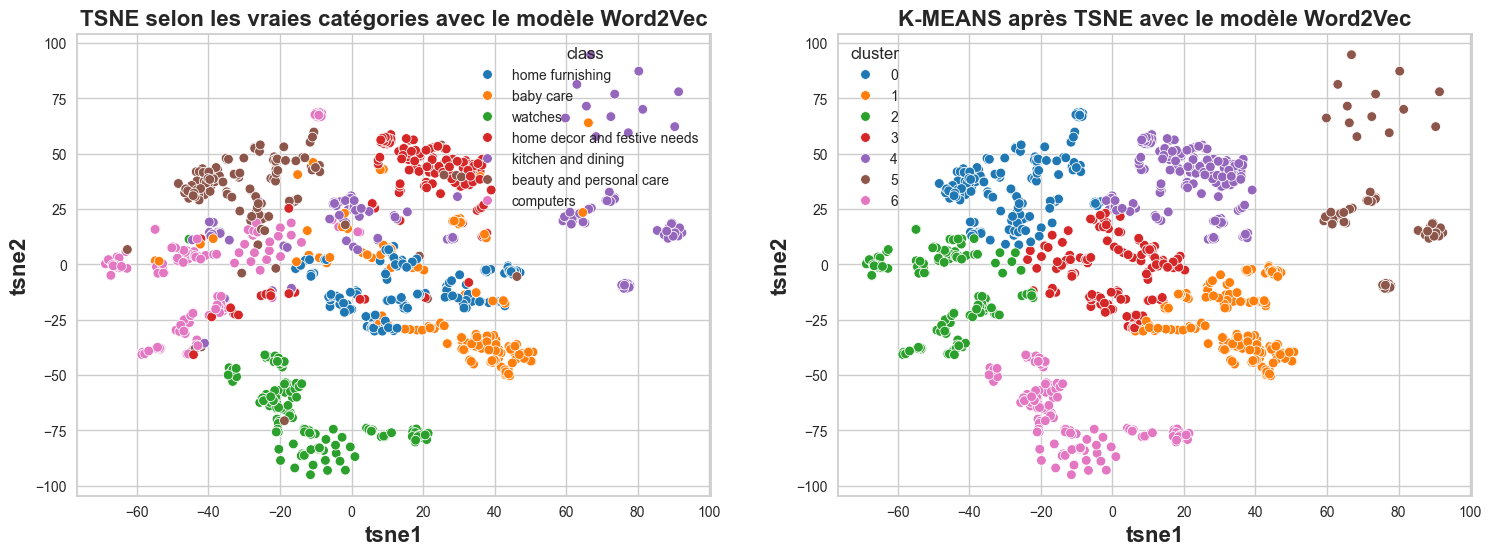

In [55]:
# Visualisation
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
with sns.color_palette(palette="tab10"):
    plt.rcParams.update({"font.size": 12})
    sns.scatterplot(ax=axes[0], data=df_tsne_w2v, x="tsne1", y="tsne2", hue="class", legend="brief")
    axes[0].set_xlabel("tsne1", fontname="sans-serif", fontsize=16, fontweight="bold")
    axes[0].set_ylabel("tsne2", fontname="sans-serif", fontsize=16, fontweight="bold")
    axes[0].set_title("TSNE selon les vraies catégories avec le modèle Word2Vec", fontname="sans-serif", fontsize=16, fontweight="bold")
    sns.scatterplot(ax=axes[1], data=df_tsne_w2v, x="tsne1", y="tsne2", hue="cluster", palette="tab10", legend="brief")
    axes[1].set_xlabel("tsne1", fontname="sans-serif", fontsize=16, fontweight="bold")
    axes[1].set_ylabel("tsne2", fontname="sans-serif", fontsize=16, fontweight="bold")
    axes[1].set_title("K-MEANS après TSNE avec le modèle Word2Vec", fontname="sans-serif", fontsize=16, fontweight="bold")
plt.show()

- Le score ARI est meilleur que pour le BoW et la classification est plutôt satisfaisante

### 3.4) BERT

BERT (*Bidirectional Encoder Representations from Transformers*) est un modèle de langage pré-entraîné développé par Google en 2018. Il repose sur l’architecture des *Transformers*, particulièrement efficace pour le traitement des séquences, comme le texte.

Ce qui distingue BERT des modèles précédents, c’est sa capacité à **prendre en compte le contexte bidirectionnel** : il analyse simultanément les mots situés **avant et après** un mot cible, contrairement aux modèles classiques qui ne considéraient qu’un seul sens (gauche → droite ou droite → gauche).

BERT est pré-entraîné sur de grands corpus non annotés via deux tâches principales :
- **Masked Language Modeling (MLM)** : prédire un mot masqué dans une phrase.
- **Next Sentence Prediction (NSP)** : prédire si une phrase suit logiquement une autre.

---

#### 3.4.1) BERT avec Hugging Face

La bibliothèque **Hugging Face Transformers** permet de charger facilement des modèles BERT pré-entraînés et de les utiliser pour diverses tâches de NLP (classification, question-réponse, résumé, etc.) via une API intuitive.


In [56]:
max_length = 64
batch_size = 10
model_type = 'bert-base-uncased'
model = TFAutoModel.from_pretrained(model_type)
sentences = df["pre_clean_description"].to_list()

# Création des features avec BERT
features_bert, last_hidden_states_tot = fc.feature_BERT_fct(model, model_type, sentences,
                                                         max_length, batch_size, mode='HF')

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

1/1 [==============================] - 1s 1s/step
temps traitement :  159.0


In [57]:
# T-SNE
start_bert_hf = time.time()
tsne_bert_hf = TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', random_state=42)
#tsne_bert_hf = TSNE(n_components=2, perplexity=10, max_iter=2000, init='pca', random_state=42)
X_tsne_bert_hf = tsne_bert_hf.fit_transform(features_bert)
stop_bert_hf = time.time() - start_bert_hf
print("Temps de T-SNE : ", "%15.2f" % stop_bert_hf, "secondes")

# Création du dataframe pour visualisation
df_tsne_bert_hf = pd.DataFrame(X_tsne_bert_hf, columns=['tsne1', 'tsne2'])
df_tsne_bert_hf["class"] = df["main_category"]

Temps de T-SNE :            12.23 secondes


In [58]:
# Réalisation du clustering avec K-Means
kmeans_bert_hf = KMeans(n_clusters=7, init='k-means++', random_state=42)
kmeans_bert_hf.fit_predict(X_tsne_bert_hf)

# Ajout des clusters au dataframe
df_tsne_bert_hf["cluster"] = kmeans_bert_hf.labels_

print(df_tsne_bert_hf.head())
print()

# Calcul de l'ARI
ari_bert_hf = adjusted_rand_score(df_tsne_bert_hf['class'], df_tsne_bert_hf['cluster'])
print(f'ARI après modélisation avec BERT HuggingFace : {ari_bert_hf}')

       tsne1      tsne2            class  cluster
0 -16.727152 -20.306179  home furnishing        1
1 -28.241474 -29.445642        baby care        5
2 -27.341028 -29.263557        baby care        5
3 -14.184554 -30.719389  home furnishing        5
4 -15.827031 -30.940321  home furnishing        5

ARI après modélisation avec BERT HuggingFace : 0.36222997797726303


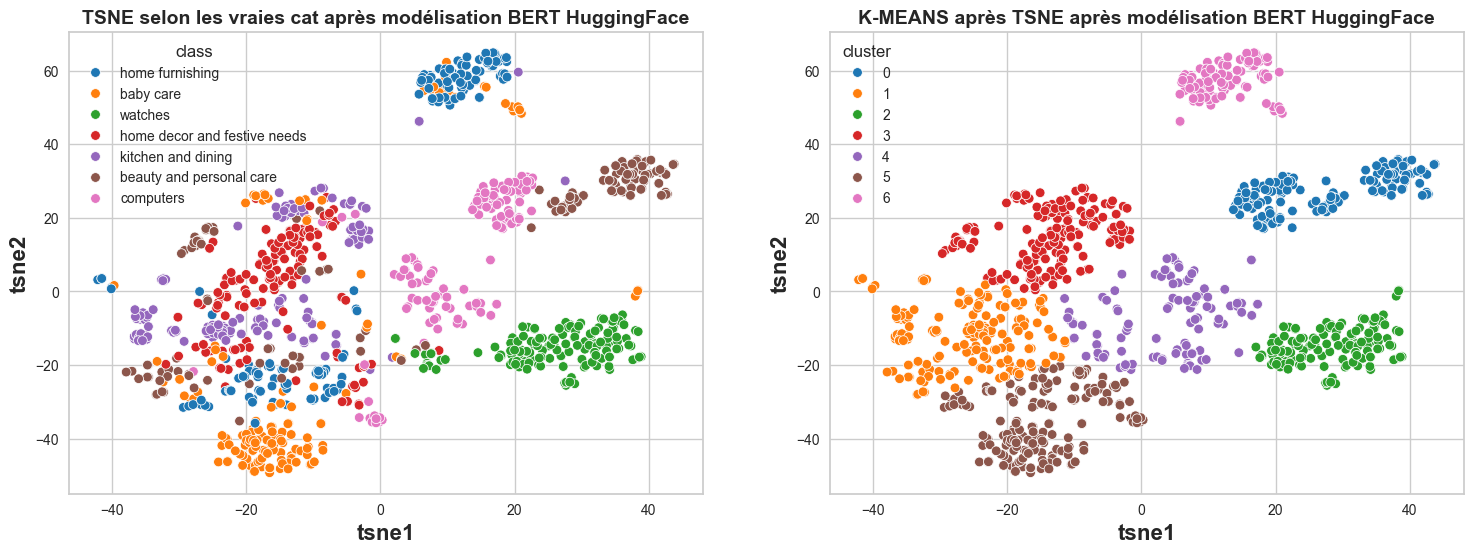

In [59]:
# Visualisation
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
with sns.color_palette(palette="tab10"):
    plt.rcParams.update({"font.size": 12})
    sns.scatterplot(ax=axes[0], data=df_tsne_bert_hf, x="tsne1", y="tsne2", hue="class", legend="brief")
    axes[0].set_xlabel("tsne1", fontname="sans-serif", fontsize=16, fontweight="bold")
    axes[0].set_ylabel("tsne2", fontname="sans-serif", fontsize=16, fontweight="bold")
    axes[0].set_title("TSNE selon les vraies cat après modélisation BERT HuggingFace", fontname="sans-serif", fontsize=14, fontweight="bold")
    sns.scatterplot(ax=axes[1], data=df_tsne_bert_hf, x="tsne1", y="tsne2", hue="cluster", palette="tab10", legend="brief")
    axes[1].set_xlabel("tsne1", fontname="sans-serif", fontsize=16, fontweight="bold")
    axes[1].set_ylabel("tsne2", fontname="sans-serif", fontsize=16, fontweight="bold")
    axes[1].set_title("K-MEANS après TSNE après modélisation BERT HuggingFace", fontname="sans-serif", fontsize=14, fontweight="bold")
plt.show()

- Le résultat est clairement moins bons que le Word2Vec que ce soit au niveau visuel ou au niveau du score ARI. 

### 3.4.1) BERT Hub Tensorflow

In [60]:
model_url = 'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12'
bert_layer = hub.KerasLayer(model_url, trainable=True)

In [61]:
sentences = df["pre_clean_description"].to_list()

In [62]:
max_length = 64
batch_size = 10
model_type = 'bert-base-uncased'
model = bert_layer

features_bert, last_hidden_states_tot = fc.feature_BERT_fct(model, model_type, sentences, 
                                                         max_length, batch_size, mode='TFhub')

temps traitement :  150.0


In [63]:
# T-SNE
start_bert_hub = time.time()

tsne_bert_hub = TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', random_state=42)
#tsne_bert_hub = TSNE(n_components=2, perplexity=10, max_iter=2000, init='pca', random_state=42)
X_tsne_bert_hub = tsne_bert_hub.fit_transform(features_bert)

stop_bert_hub = time.time() - start_bert_hub

print("Temps de T-SNE : ", "%15.2f" % stop_bert_hub, "secondes")

Temps de T-SNE :            12.14 secondes


In [64]:
# Création du dataframe
df_tsne_bert_hub = pd.DataFrame(X_tsne_bert_hub, columns=['tsne1', 'tsne2'])
df_tsne_bert_hub["class"] = df["main_category"]
df_tsne_bert_hub.head()

,tsne1,tsne2,class
0,-15.943117,-20.948887,home furnishing
1,-24.318996,-30.485466,baby care
2,-24.955820,-31.094364,baby care
3,-14.145136,-31.369520,home furnishing
4,-15.873646,-31.526505,home furnishing


In [65]:
# Réalisation du k-means avec 7 clusters (7 catégories de produits)
kmeans_bert_hub = KMeans(n_clusters=7, init='k-means++', random_state=42)
kmeans_bert_hub.fit(X_tsne_bert_hub)

# Récupération des clusters
kmeans_bert_hub_labels = kmeans_bert_hub.labels_

# Ajout des clusters au dataframe précédent
df_tsne_bert_hub["cluster"] = kmeans_bert_hub_labels

print(df_tsne_bert_hub.head())
print()
ari_bert_hub = adjusted_rand_score(df_tsne_bert_hub['class'],df_tsne_bert_hub['cluster'])
print(f'ARI après modélisation avec BERT Hub Tensorflow : {ari_bert_hub}')

       tsne1      tsne2            class  cluster
0 -15.943117 -20.948887  home furnishing        3
1 -24.318996 -30.485466        baby care        3
2 -24.955820 -31.094364        baby care        3
3 -14.145136 -31.369520  home furnishing        3
4 -15.873646 -31.526505  home furnishing        3

ARI après modélisation avec BERT Hub Tensorflow : 0.35856775885306696


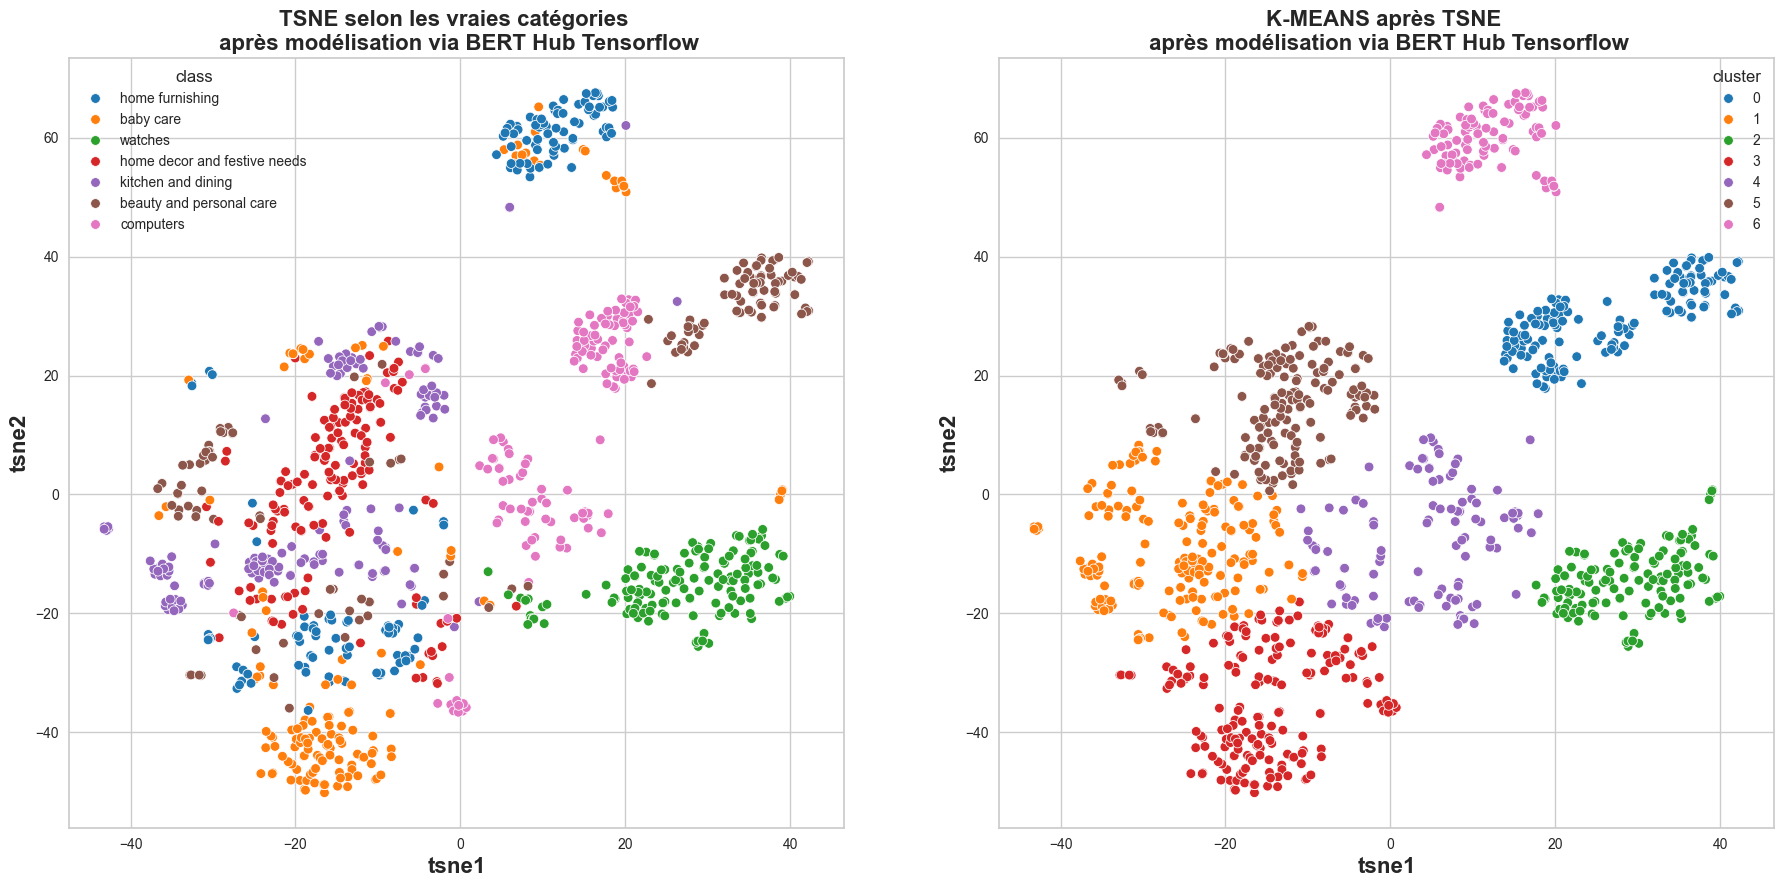

In [66]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 10))
with sns.color_palette(palette="tab10"):
    plt.rcParams.update({"font.size":12})
    sns.scatterplot(ax=axes[0], data= df_tsne_bert_hub, x="tsne1", y="tsne2", hue="class", legend="brief")
    axes[0].set_xlabel("tsne1", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    axes[0].set_ylabel("tsne2", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    axes[0].set_title("TSNE selon les vraies catégories \n après modélisation via BERT Hub Tensorflow", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    sns.scatterplot(ax=axes[1], data= df_tsne_bert_hub, x="tsne1", y="tsne2", hue="cluster", palette="tab10", legend="brief")
    axes[1].set_xlabel("tsne1", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    axes[1].set_ylabel("tsne2", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    axes[1].set_title("K-MEANS après TSNE \n après modélisation via BERT Hub Tensorflow", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
plt.show()

## 3.5) USE
USE est un modèle de traitement de langage naturel (NLP) développé par Google. Contrairement à BERT qui se concentre sur la représentation de mots, USE est spécifiquement conçu pour encoder des phrases et des paragraphes entiers.

Ce qui distingue USE, c'est sa capacité à générer des représentations vectorielles universelles pour des phrases de différentes langues et de différentes longueurs. Ces représentations sont apprises à partir de données non annotées et sont conçues pour capturer des informations sémantiques et syntaxiques importantes dans le text, etc.

In [67]:
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder-large/5")

In [68]:
def feature_USE_fct(sentences, b_size) :
    batch_size = b_size
    time1 = time.time()

    for step in range(len(sentences)//batch_size) :
        idx = step*batch_size
        feat = embed(sentences[idx:idx+batch_size])

        if step ==0 :
            features = feat
        else :
            features = np.concatenate((features,feat))

    time2 = np.round(time.time() - time1,0)
    return features

In [69]:
batch_size = 8
sentences = df['pre_clean_description'].to_list()
features_USE = feature_USE_fct(sentences, batch_size)

In [70]:
# T-SNE
start_use = time.time()
tsne_use = TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', random_state=42)
X_tsne_use = tsne_use.fit_transform(features_USE)
stop_use = time.time() - start_use
print("Temps de T-SNE : ", "%15.2f" % stop_use, "secondes")

Temps de T-SNE :             9.91 secondes


In [71]:
# Création du dataframe
df_tsne_use = pd.DataFrame(X_tsne_use, columns=['tsne1', 'tsne2'])
df_tsne_use["class"] = df["main_category"]
df_tsne_use.head

<bound method NDFrame.head of           tsne1      tsne2            class
0     11.401547  16.347034  home furnishing
1     11.741057  21.409166        baby care
2     10.737344  21.317427        baby care
3      3.023932  18.230282  home furnishing
4      3.678797  17.033346  home furnishing
...         ...        ...              ...
1043  -7.095801 -30.073883        baby care
1044  -6.544674 -30.207188        baby care
1045   2.776182   9.128186        baby care
1046   3.301243   9.641370        baby care
1047  -6.560675 -29.140162        baby care

[1048 rows x 3 columns]>

In [72]:
# Réalisation du k-means avec 7 clusters (7 catégories de produits)
kmeans_tsne_use = KMeans(n_clusters=7, init='k-means++', random_state=42)
kmeans_tsne_use.fit_predict(X_tsne_use)

# Récupération des clusters
kmeans_tsne_use_labels = kmeans_tsne_use.labels_

# Ajout des clusters au dataframe précédent
df_tsne_use["cluster"] = kmeans_tsne_use_labels

print(df_tsne_use.head())
print()
ari_use = adjusted_rand_score(df_tsne_use['class'],df_tsne_use['cluster'])
print(f'ARI après modélisation avec USE : {ari_use}')

       tsne1      tsne2            class  cluster
0  11.401547  16.347034  home furnishing        6
1  11.741057  21.409166        baby care        6
2  10.737344  21.317427        baby care        6
3   3.023932  18.230282  home furnishing        4
4   3.678797  17.033346  home furnishing        4

ARI après modélisation avec USE : 0.4662800479064076


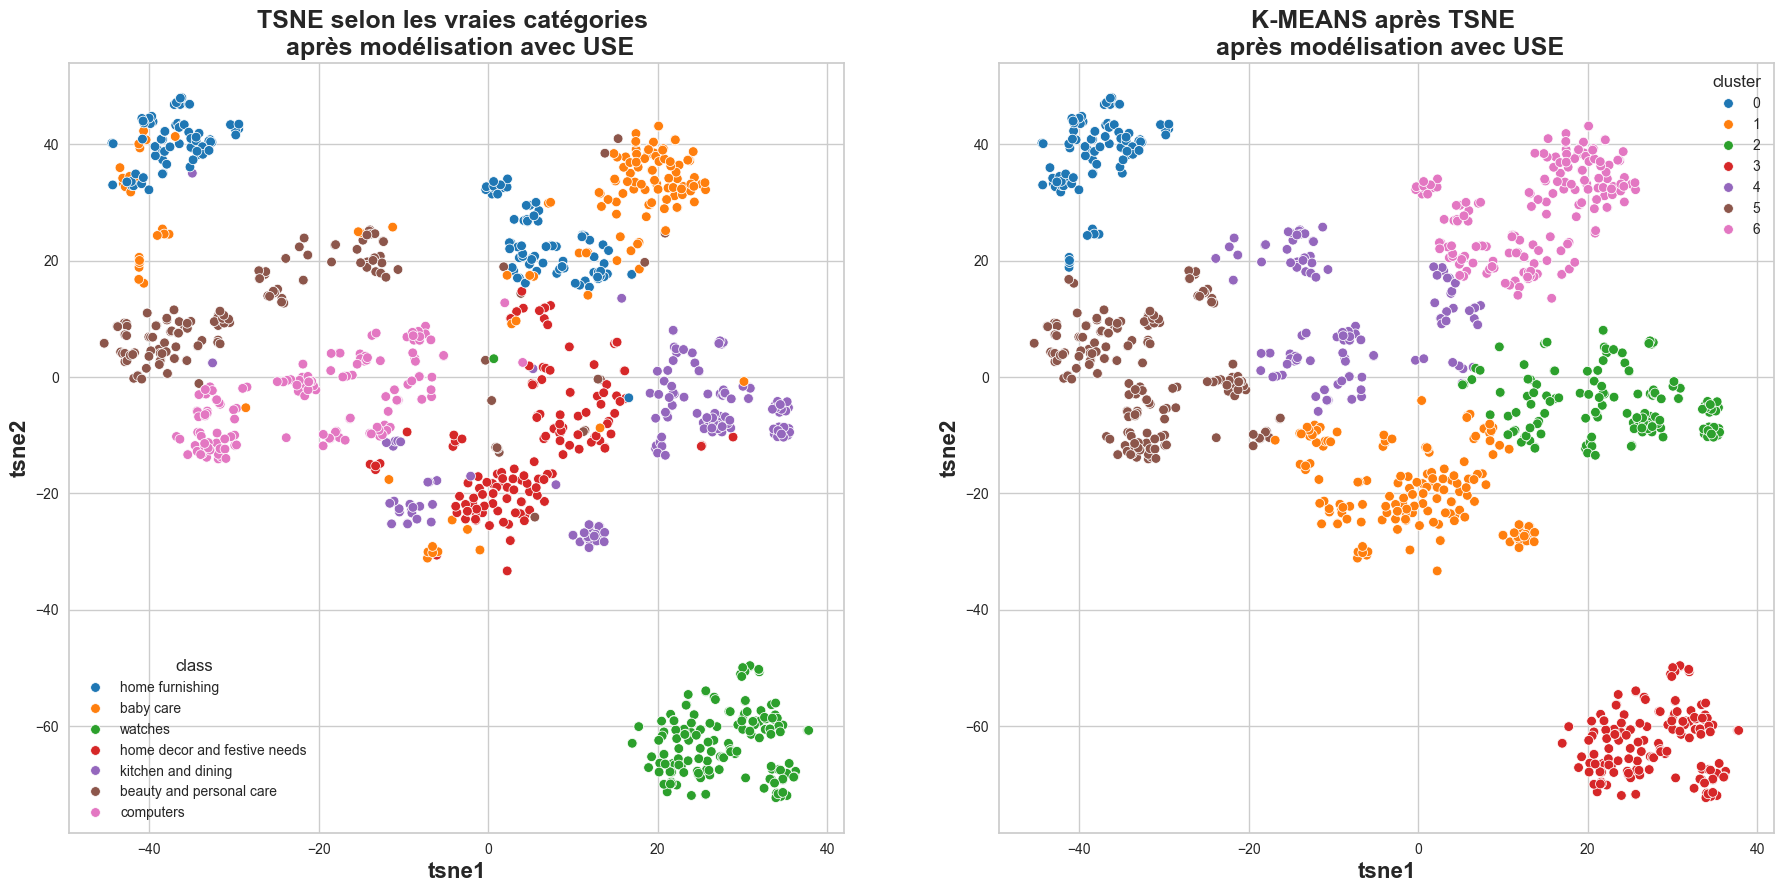

In [73]:
# Visualisation par nuages de points
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 10))
with sns.color_palette(palette="tab10"):
    plt.rcParams.update({"font.size":12})
    sns.scatterplot(ax=axes[0], data= df_tsne_use, x="tsne1", y="tsne2", hue="class", legend="brief")
    axes[0].set_xlabel("tsne1", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    axes[0].set_ylabel("tsne2", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    axes[0].set_title("TSNE selon les vraies catégories \n après modélisation avec USE", fontname= "sans-serif", fontsize = 18, fontweight = "bold")
    sns.scatterplot(ax=axes[1], data= df_tsne_use, x="tsne1", y="tsne2", hue="cluster", palette="tab10", legend="brief")
    axes[1].set_xlabel("tsne1", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    axes[1].set_ylabel("tsne2", fontname= "sans-serif", fontsize = 16, fontweight = "bold")
    axes[1].set_title("K-MEANS après TSNE \n après modélisation avec USE", fontname= "sans-serif", fontsize = 18, fontweight = "bold")
plt.show()

# Conclusion

J'ai observé que l'approche **USE** obtient un **score ARI de 0,46**, ce qui représente une performance **supérieure à celle de BERT (score ARI de 0,36)**, ainsi que **BOW et TF-IDF avec un score ARI de 0,44**  mais reste **inférieure à celle obtenue avec Word2Vec (score ARI de 0,54)**.

Ce notebook a permis de démontrer la **faisabilité d’une classification automatique des produits** selon leur catégorie. L’objectif ici n’était pas de concevoir un modèle optimal, mais de valider la possibilité technique de cette tâche.

Il est important de noter que **les catégories les plus proches sémantiquement posent davantage de difficultés**, générant des erreurs de classification. Une **piste d’amélioration** pertinente serait de **segmenter davantage ces catégories** en **sous-catégories plus précises**, afin de limiter les confusions et d’augmenter les performances du modèle.
